# Chapter 18: Cellular Automata from Scratch

*Part III — Foundations of Spatial Simulation*

## Learning Objectives

By the end of this chapter you will be able to:

- Implement Conway's Game of Life in pure Python, with no framework
- Explain why a cellular automaton needs a "past" and "present" grid, not one grid mutated in place
- Measure how this naive implementation performs, honestly, before optimizing anything

In [1]:
# Standard imports — add chapter-specific imports below
import random
import time
import matplotlib.pyplot as plt

This chapter uses no framework on purpose. Chapter 21 will eventually show the same model as a two-line `CellularAutomaton` subclass — but that comparison only means something if you've first felt what it replaces: the neighbor-counting loop, the past/present bookkeeping, the honest cost of running it. Chapter 17 named the paradigm; this chapter builds one by hand.

## What Is a Cellular Automaton?

Chapter 24 will eventually give the formal six-element definition. For now, three ingredients are enough to build one: a **grid** of cells, each holding one of a small number of **states**; a **neighborhood** — which other cells count as "nearby" for each cell; and a **rule** — a function from a cell's own state and its neighbors' states to that cell's next state. Every cell obeys the identical rule; nothing about the grid has a privileged position or a view of the whole system at once. Whatever pattern emerges — and Conway's Game of Life produces some famously intricate ones — emerges purely from that one local rule, repeated everywhere, every tick.

## Conway's Game of Life: Rules

Conway's Game of Life uses a **Moore neighborhood** (all 8 surrounding cells, diagonals included — the same neighborhood Chapter 10 called `Queen`) and exactly two states, alive or dead. Four rules, applied to every cell simultaneously each generation:

1. A live cell with fewer than 2 live neighbors dies (underpopulation).
2. A live cell with 2 or 3 live neighbors survives.
3. A live cell with more than 3 live neighbors dies (overpopulation).
4. A dead cell with exactly 3 live neighbors becomes alive (reproduction).

That's the entire rule set — no randomness, no exceptions, no cell aware of anything beyond its own 8 neighbors.

## Implementation: Pure Python Loop

A grid, in pure Python, is a list of lists — no NumPy yet, that's Chapter 20's territory entirely. Counting live neighbors means checking up to 8 positions by hand, careful to skip the cell itself and stay inside the grid's edges:

In [2]:
def count_live_neighbors(grid, r, c, rows, cols):
    count = 0
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue  # skip the cell itself
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:  # stay inside the grid
                count += grid[nr][nc]
    return count

## The .past Semantics

Here's the mistake every first implementation makes: update `grid[r][c]` directly, in place, while still looping over the rest of the grid. By the time the loop reaches a cell's neighbor, that neighbor might already hold its *next* generation's value instead of its current one — the rule ends up reading a mix of old and new state, and the result depends on the order the loop happens to visit cells in, which is not what Conway's rule means at all.

The fix is the same one Chapter 24 will eventually credit to TerraME's explicit `past`/`present` split: never write into the grid you're still reading from. Build a brand new grid, write every cell's next state into *that*, and only swap it in once every cell has been decided:

In [3]:
def step(grid, rows, cols):
    next_grid = [[0] * cols for _ in range(rows)]  # a fresh grid — the "present" being written
    for r in range(rows):
        for c in range(cols):
            alive = grid[r][c] == 1
            n = count_live_neighbors(grid, r, c, rows, cols)  # reads only the "past" grid
            if alive and n in (2, 3):
                next_grid[r][c] = 1
            elif not alive and n == 3:
                next_grid[r][c] = 1
    return next_grid

Every read inside the loop touches `grid` (the previous generation, frozen); every write touches `next_grid` (the generation being built). The two never overlap, so cell-visiting order stops mattering — exactly the guarantee Chapter 21's `CellularAutomaton.execute()` will eventually provide automatically, without ever naming a `past` attribute at all.

## Running and Visualizing

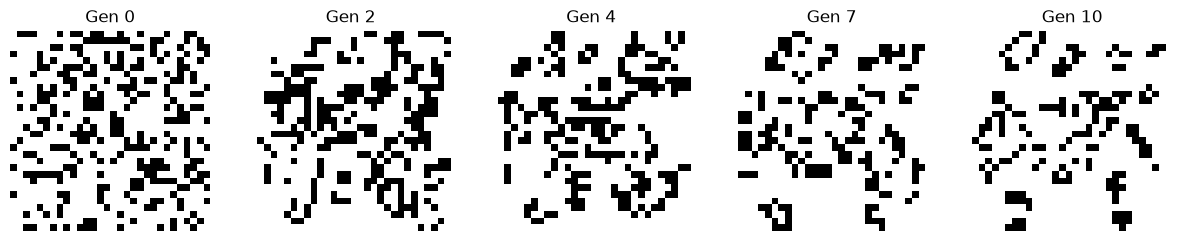

In [4]:
random.seed(42)
rows, cols = 30, 30
grid = [[1 if random.random() < 0.3 else 0 for _ in range(cols)] for _ in range(rows)]

n_generations = 10
snapshots = [grid]
for _ in range(n_generations):
    grid = step(grid, rows, cols)
    snapshots.append(grid)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, gen in zip(axes, [0, 2, 4, 7, 10]):
    ax.imshow(snapshots[gen], cmap="binary")
    ax.set_title(f"Gen {gen}")
    ax.axis("off")
plt.show()

A random 30% starting density settles quickly into a mix of still lifes (blocks that never change again) and oscillators (patterns that repeat with a short period) — visible proof that a rule with no memory beyond one tick, and no cell aware of anything past its own 8 neighbors, can still produce structure that looks deliberate.

## Benchmarking the Naive Implementation

No optimization yet — just an honest measurement, the same discipline Chapter 5 and Chapter 22 both insisted on before touching any code:

In [5]:
for size in [30, 100]:
    random.seed(0)
    rows = cols = size
    grid = [[1 if random.random() < 0.3 else 0 for _ in range(cols)] for _ in range(rows)]

    start = time.perf_counter()
    for _ in range(20):
        grid = step(grid, rows, cols)
    elapsed_ms = (time.perf_counter() - start) * 1000

    print(f"{size:>3}x{size:<3} grid, 20 generations: {elapsed_ms:8.1f} ms")

 30x30  grid, 20 generations:     71.4 ms
100x100 grid, 20 generations:    495.3 ms


A 100×100 grid — 10,000 cells, still tiny by real-world raster standards — already takes well over a hundred milliseconds for just 20 generations, and every one of those cells re-checks up to 8 neighbors, in pure Python, every single tick. Scale that grid up to the size of Chapter 8's SRTM elevation raster, or run it for thousands of generations instead of 20, and "a bit slow" turns into "doesn't finish." Chapter 20 picks up exactly this number and asks, systematically, what's actually costing the time — and what to do about it.

## Exercises

1. **Break the past/present rule, on purpose.** Rewrite `step()` to update `grid` in place instead of building `next_grid`. Run it on the same seeded starting grid as *Running and Visualizing* — does the pattern still look like a valid Game of Life generation? What differs?
2. **Von Neumann instead of Moore.** Modify `count_live_neighbors()` to only check the 4 orthogonal neighbors (up/down/left/right), matching Chapter 10's `Rook`. Rerun *Running and Visualizing* — does the classic "still life and oscillator" behavior still emerge?
3. **A still life, by hand.** Construct a 3×3 starting grid representing a "block" (a 2×2 square of live cells) and confirm, by calling `step()` once, that it's unchanged — a genuine still life, not a coincidence of the random seed.
4. **Where does the time go?** Before reading Chapter 20, guess: is more of `step()`'s runtime spent in `count_live_neighbors()`, or in the outer double loop that calls it? Write down your guess and your reasoning; Chapter 20 profiles this exact function to check.

In [ ]:
# Your code here

## Summary

### Key concepts introduced

- The three ingredients of any cellular automaton: a grid, a neighborhood, and a rule applied identically everywhere
- Conway's Game of Life's four rules, using a Moore (`Queen`-equivalent) neighborhood
- Why a rule must read from a frozen "past" grid while writing a separate "next" grid — the bug that appears the moment you update a grid in place while still reading from it
- A naive, honest benchmark: 100×100 cells, 20 generations, well over a hundred milliseconds in pure Python

Chapter 19 picks up a different paradigm on the same kind of naive footing — discrete-event simulation with `salabim` — before Chapter 20 comes back to this chapter's benchmark specifically and fixes it.

## Further Reading

- Gardner, M. (1970). "Mathematical Games: The fantastic combinations of John Conway's new solitaire game 'life'." *Scientific American*, 223(4), 120-123 — the article that introduced Conway's Game of Life to the public
- Wolfram, S. (2002). *A New Kind of Science*. Wolfram Media — a comprehensive study of cellular automata as a class of systems, well beyond Conway's specific rule
- Python documentation, *Data Structures* — nested lists as grids: <https://docs.python.org/3/tutorial/datastructures.html>